In [1]:
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
matrix = np.array([
    [0, 1, 1, 0, 0],
    [1, 0, 1, 0, 0],
    [1, 2, 0, 1, 0],
    [0, 0, 1, 0, 1],
    [0, 0, 0, 1, 0],
])

In [14]:
d = 2

In [3]:
G = nx.from_numpy_array(matrix)

In [4]:
pos = nx.spring_layout(G)
_ = nx.spring_layout(G, seed=123, store_pos_as="pos")

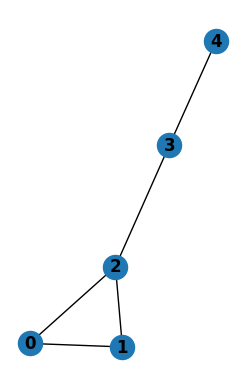

In [5]:
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold', pos=pos)
plt.show()

In [6]:
G.nodes(data=True)

NodeDataView({0: {'pos': array([-0.70766329, -0.13328231])}, 1: {'pos': array([-0.54414206,  0.23130518])}, 2: {'pos': array([-0.19957916,  0.02641489])}, 3: {'pos': array([ 0.45138452, -0.03629365])}, 4: {'pos': array([ 1.        , -0.08814411])}})

In [7]:
G.nodes, G.edges

(NodeView((0, 1, 2, 3, 4)), EdgeView([(0, 1), (0, 2), (1, 2), (2, 3), (3, 4)]))

In [8]:
weights = np.array([
    [0.2, 0.6],
    [0.5, 0.1],
    [0.4, 0.7],
    [0.9, 0.2],
    [0.3, 0.8],
])

learning_rate = 0.1
weights, learning_rate

(array([[0.2, 0.6],
        [0.5, 0.1],
        [0.4, 0.7],
        [0.9, 0.2],
        [0.3, 0.8]]),
 0.1)

In [16]:
weights_map = {i: weights[i] for i in range(len(weights))}

In [17]:
nx.set_node_attributes(G, weights_map, "weights")

In [47]:
def sigmoid(x):
    return (1/(1+np.exp(-x)))

In [60]:
def update(old, upd):
    return old - learning_rate * upd

In [48]:
class positive_sample:
    def grad_i(self, zi, zj):
        return - (1 - sigmoid(np.transpose(zi) @ zj)) * zj
    
    def grad_j(self, zi, zj):
        return - (1 - sigmoid(np.transpose(zi) @ zj)) * zi

In [49]:
class negative_sample:
    def grad_i(self, zi, zk):
        return sigmoid(np.transpose(zi) @ zk) * zk
    
    def grad_j(self, zi, zk):
        return sigmoid(np.transpose(zi) @ zk) * zi

In [50]:
pos = positive_sample()
neg = negative_sample()

In [51]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[0.2, 0.6],
       [0.5, 0.1],
       [0.4, 0.7],
       [0.9, 0.2],
       [0.3, 0.8]])

In [52]:
features[0]

array([0.2, 0.6])

In [56]:
grad_z1 = pos.grad_i(features[0], features[1]) + neg.grad_i(features[0], features[4])
grad_z1

array([-0.04049883,  0.45944142])

In [57]:
grad_z2 = pos.grad_i(features[1], features[0])
grad_z2 

array([-0.09201702, -0.27605107])

In [59]:
grad_z5 = neg.grad_j(features[0], features[4])
grad_z5 

array([0.12636248, 0.37908745])

In [61]:
features[0] = update(features[0], grad_z1)
features[0]

array([0.20404988, 0.55405586])